# Multi-layer Perceptron Regression

Class MLPRegressor implements a multi-layer perceptron (MLP) that trains using backpropagation with no activation function in the output layer, which can also be seen as using the identity function as activation function. Therefore, it uses the square error as the loss function, and the output is a set of continuous values.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd # Import pandas to avoid potential errors if not imported elsewhere

#Creating feature and target arrays
california = fetch_california_housing()
X, y = california.data, california.target
columns = california.feature_names

# The filter y<50 is specific to the Boston dataset and not needed for California Housing
# X=X[y<50]
# y=y[y<50]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=False).fit(X)
scaler.transform(X)

'''
Multi-layer Perceptron is sensitive to feature scaling, so it is highly recommended to scale your data.
For example, scale each attribute on the input vector X to [0, 1] or [-1, +1],
or standardize it to have mean 0 and variance 1. Note that you must apply the same scaling
to the test set for meaningful results. You can use StandardScaler for standardization.
'''

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42)

#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.neural_network import MLPRegressor
import numpy as np

regressor = MLPRegressor(random_state=0)
parameters = {'hidden_layer_sizes': [(8),(10, 5), (20,10,5), (10,5,3)],
              'solver' : ['sgd'],
              #'batch_size': [20],
              #'learning_rate' : ['constant'],
              'alpha':10.0 ** -np.arange(-1, 3),
              'max_iter':[10000]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3, verbose = 0) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

Los parámetros utilizados en MLPRegressor y GridSearchCV:

hidden_layer_sizes: Este parámetro determina la arquitectura de las capas ocultas en el Perceptrón Multicapa. Es una tupla donde cada elemento representa el número de neuronas en esa capa oculta respectiva. Por ejemplo, (10, 5) significa que hay dos capas ocultas, la primera con 10 neuronas y la segunda con 5. Se exploran diferentes combinaciones para encontrar la estructura de red óptima.

solver: Esto especifica el algoritmo para la optimización de pesos. Aquí se utiliza 'sgd' (Descenso de Gradiente Estocástico). SGD actualiza iterativamente los parámetros del modelo para minimizar la función de pérdida.

alpha: Este es el parámetro del término de regularización L2. La regularización ayuda a prevenir el sobreajuste al penalizar los pesos grandes. Un valor de alpha más grande significa una regularización más fuerte. Tu búsqueda en cuadrícula explora diferentes potencias de 10 para alpha.

max_iter: Este es el número máximo de iteraciones (épocas) que ejecutará el solucionador. Una época es una pasada completa a través de todo el conjunto de datos de entrenamiento. Un max_iter más alto le da al modelo más oportunidades de converger, pero también puede aumentar el tiempo de entrenamiento.

In [2]:
#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: 0.761797 using {'alpha': np.float64(0.1), 'hidden_layer_sizes': (20, 10, 5), 'max_iter': 10000, 'solver': 'sgd'}
0.606167 (0.006092) with: {'alpha': np.float64(10.0), 'hidden_layer_sizes': 8, 'max_iter': 10000, 'solver': 'sgd'}
0.614863 (0.006620) with: {'alpha': np.float64(10.0), 'hidden_layer_sizes': (10, 5), 'max_iter': 10000, 'solver': 'sgd'}
0.630632 (0.004287) with: {'alpha': np.float64(10.0), 'hidden_layer_sizes': (20, 10, 5), 'max_iter': 10000, 'solver': 'sgd'}
0.626034 (0.006356) with: {'alpha': np.float64(10.0), 'hidden_layer_sizes': (10, 5, 3), 'max_iter': 10000, 'solver': 'sgd'}
0.700639 (0.006450) with: {'alpha': np.float64(1.0), 'hidden_layer_sizes': 8, 'max_iter': 10000, 'solver': 'sgd'}
0.725176 (0.004226) with: {'alpha': np.float64(1.0), 'hidden_layer_sizes': (10, 5), 'max_iter': 10000, 'solver': 'sgd'}
0.759112 (0.005924) with: {'alpha': np.float64(1.0), 'hidden_layer_sizes': (20, 10, 5), 'max_iter': 10000, 'solver': 'sgd'}
0.72761

0.7766819290152642

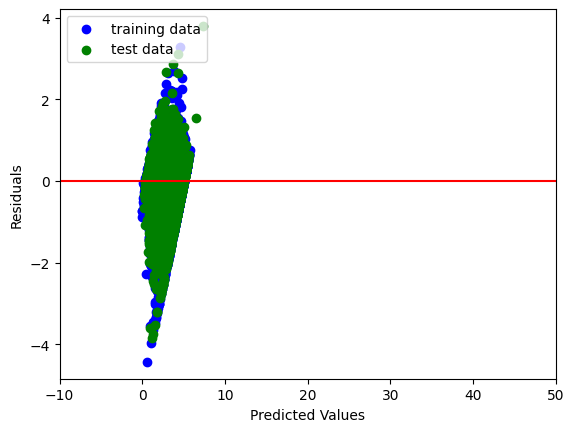

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(gs.predict(X_train),gs.predict(X_train)-y_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),gs.predict(X_test)-y_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [4]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  0.36607245008601497
MSE train:  0.28530184760627914
RMSE train:  0.5341365439719316
r2:  0.8871526680915051
MAE test:  0.3731419154297893
MSE test:  0.293113924967089
RMSE test:  0.5413999676459992
r2:  0.8812955968432296


In [5]:
import pandas as pd

error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test

pd.DataFrame(error_train).describe()

,0
count,14448.000000
mean,0.003595
std,0.534143
min,-4.436116
25%,-0.198555
50%,0.063905
75%,0.285189
max,3.296295


In [6]:
nb_error_train = np.array(error_train).flatten()

error_train = np.array(error_train).reshape(-1,1)
scaled_error_train= StandardScaler(copy=False).fit(error_train).transform(error_train).flatten()

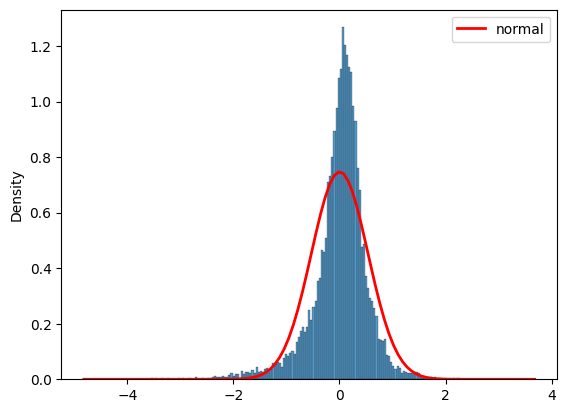

In [7]:
import numpy as np
import scipy
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot_2samples
from matplotlib import pyplot as plt
import seaborn as sns


# We test a exponential distribution
dist = getattr(scipy.stats, 'norm')
param = dist.fit(nb_error_train)

err_mean=param[-2]
err_std=param[-1]

# We generate a sample of size  len(mr_scaled) of data distributed according to distribution dist
# The function rvs generates a sample with distribution dist with mean loc and std scale
test_dist = dist.rvs(*param[0:-2],loc=param[-2], scale=param[-1],size = len(nb_error_train))


# plot the distribution and compare with a normal

ax = sns.histplot(nb_error_train, stat='density')

# calculate the pdf
x0, x1 = ax.get_xlim()  # extract the endpoints for the x-axis
x_pdf = np.linspace(x0, x1, 100)
y_pdf = scipy.stats.norm.pdf(x_pdf, loc=err_mean, scale=err_std)

ax.plot(x_pdf, y_pdf, 'r', lw=2, label='normal')
ax.legend()

#plt.hist(nb_error_train,alpha=.3, density=True,bins='auto')
#plt.hist(test_dist,alpha=.3, density=True,bins='auto')
#plt.show()